In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 

data_iso_40 = pd.read_csv("results_iso.csv")
data_iso_120 = pd.read_csv("results_iso_120.csv")
data_aniso_40 = pd.read_csv("results_aniso_40_200.csv")
data_aniso_40_200 = pd.read_csv("results_aniso_40_200_width.csv")
data_iso_120_width = pd.read_csv("results_iso_120_width.csv")

data_aniso_40_200

,Mesh,Pressure,Area_start,Area_end,Width_start,Width_end,Length_start,Length_end,Volume_1_start,Volume_2_start,Volume_1_end,Volume_2_end,Pore_width_start,Pore_width_end,Pore_height_start,Pore_height_end,Min_diameter_start,Min_diameter_end
0,1_2,0.01,40.56,47.62,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3775.53,3897.55,4.9,5.8,11.0,11.0,4.9,5.8
1,1_2,0.11,40.56,58.85,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3994.14,4148.22,4.9,6.8,11.0,11.7,4.9,6.8
2,1_2,0.21,40.56,64.25,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4069.94,4250.61,4.9,7.2,11.0,12.0,4.9,7.2
3,1_2,0.31,40.56,68.40,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4132.12,4337.66,4.9,7.4,11.0,12.2,4.9,7.4
4,1_2,0.41,40.56,71.97,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4194.46,4408.93,4.9,7.7,11.0,12.4,4.9,7.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,3_7,0.51,21.96,41.90,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4026.79,4847.10,3.0,5.3,10.4,10.8,3.0,5.3
176,3_7,0.61,21.96,43.54,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4075.30,4916.35,3.0,5.4,10.4,10.9,3.0,5.4
177,3_7,0.71,21.96,45.11,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4123.51,4983.98,3.0,5.6,10.4,11.0,3.0,5.6
178,3_7,0.81,21.96,46.48,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4171.78,5050.74,3.0,5.7,10.4,11.1,3.0,5.7


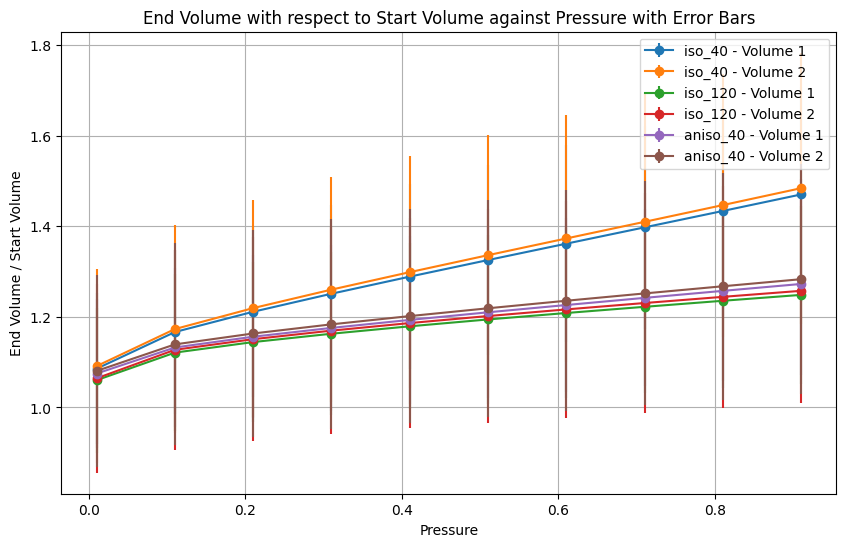

In [7]:
## For each dataset, plot the change in volume with respect to the initial volume, against the pressure. Include the error bars.

import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
data1 = data_iso_40
data2 = data_iso_120
data3 = data_aniso_40

dataset1 = "iso_40"
dataset2 = "iso_120"
dataset3 = "aniso_40"

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        ' Volume_1_start': ['mean', 'std'],
        ' Volume_2_start': ['mean', 'std'],
        ' Volume_1_end': ['mean', 'std'],
        ' Volume_2_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Volume_1_start_mean', 'Volume_1_start_std', 'Volume_2_start_mean', 'Volume_2_start_std', 'Volume_1_end_mean', 'Volume_1_end_std', 'Volume_2_end_mean', 'Volume_2_end_std']

    # Calculate the ratio of end volume to start volume
    grouped['Volume_1_ratio'] = grouped['Volume_1_end_mean'] / grouped['Volume_1_start_mean']
    grouped['Volume_2_ratio'] = grouped['Volume_2_end_mean'] / grouped['Volume_2_start_mean']

    # Calculate the error bars
    grouped['Volume_1_ratio_err'] = grouped['Volume_1_ratio'] * ((grouped['Volume_1_end_std'] / grouped['Volume_1_end_mean'])**2 + (grouped['Volume_1_start_std'] / grouped['Volume_1_start_mean'])**2)**0.5
    grouped['Volume_2_ratio_err'] = grouped['Volume_2_ratio'] * ((grouped['Volume_2_end_std'] / grouped['Volume_2_end_mean'])**2 + (grouped['Volume_2_start_std'] / grouped['Volume_2_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Volume_1_ratio'], yerr=grouped1['Volume_1_ratio_err'], label= dataset1 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped1['Pressure'], grouped1['Volume_2_ratio'], yerr=grouped1['Volume_2_ratio_err'], label= dataset1 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped2['Pressure'], grouped2['Volume_1_ratio'], yerr=grouped2['Volume_1_ratio_err'], label= dataset2 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Volume_2_ratio'], yerr=grouped2['Volume_2_ratio_err'], label= dataset2 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped3['Pressure'], grouped3['Volume_1_ratio'], yerr=grouped3['Volume_1_ratio_err'], label= dataset3 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Volume_2_ratio'], yerr=grouped3['Volume_2_ratio_err'], label= dataset3 + ' - Volume 2', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('End Volume / Start Volume')
plt.title('End Volume with respect to Start Volume against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()



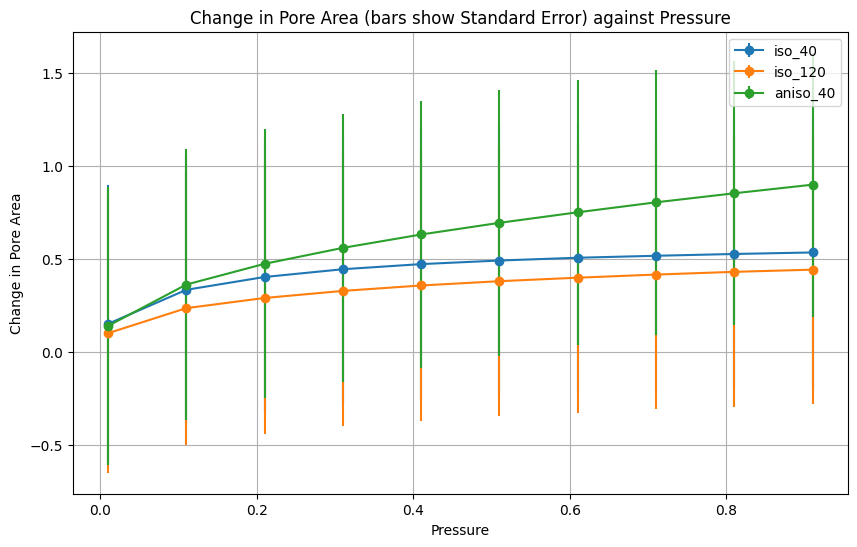

In [8]:
def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Area_start': ['mean', 'std'],
        'Area_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Area_start_mean', 'Area_start_std', 'Area_end_mean', 'Area_end_std']

    # Calculate the change in pore area
    grouped['Area_change'] = (grouped['Area_end_mean'] - grouped['Area_start_mean']) / grouped['Area_start_mean']

    # Calculate the error bars for the relative change
    grouped['Area_change_err'] = ((grouped['Area_end_std'] / grouped['Area_end_mean'])**2 + 
                                  (grouped['Area_start_std'] / grouped['Area_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Area_change'], yerr=grouped1['Area_change_err'], label=dataset1, fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Area_change'], yerr=grouped2['Area_change_err'], label=dataset2, fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Area_change'], yerr=grouped3['Area_change_err'], label=dataset3, fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Change in Pore Area')
plt.title('Change in Pore Area (bars show Standard Error) against Pressure')
plt.legend()
plt.grid(True)
plt.show()


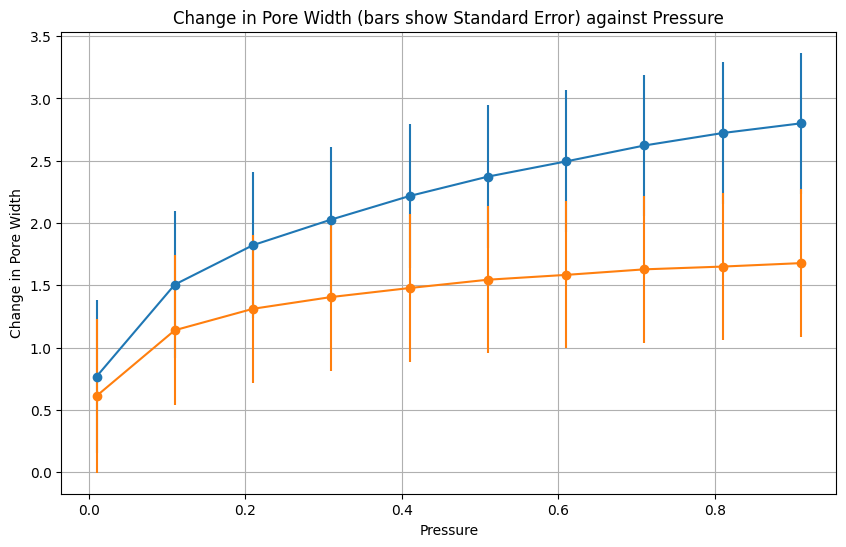

In [9]:
## For the data_aniso_40_200_width data set, plot the change in pore width

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    # Calculate the change in pore width
    grouped['Width_change'] = (grouped['Width_end_mean'] - grouped['Width_start_mean'])

    # Calculate the error bars for the relative change
    grouped['Width_change_err'] = ((grouped['Width_end_std'] / grouped['Width_end_mean'])**2 + 
                                  (grouped['Width_start_std'] / grouped['Width_start_mean'])**2)**0.5

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_change'], yerr=grouped['Width_change_err'], fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_change'], yerr=grouped2['Width_change_err'], fmt='-o')

plt.xlabel('Pressure')

plt.ylabel('Change in Pore Width')

plt.title('Change in Pore Width (bars show Standard Error) against Pressure')

plt.grid(True)

plt.show()


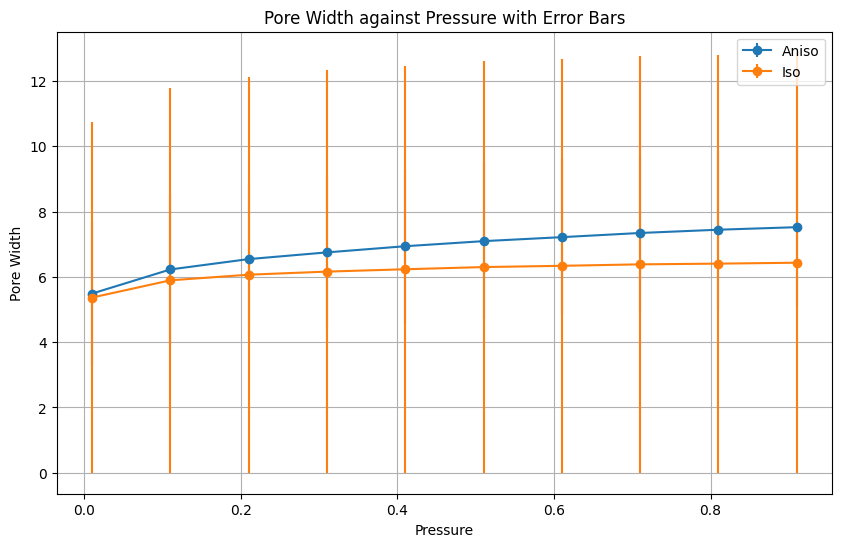

In [10]:
## Plot the absolute pore width against the pressure for the data_aniso_40_200_width data set

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_end_mean'], yerr=grouped['Width_end_std'], label='Aniso', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_end_mean'], yerr=grouped2['Width_end_mean'], label='Iso', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()

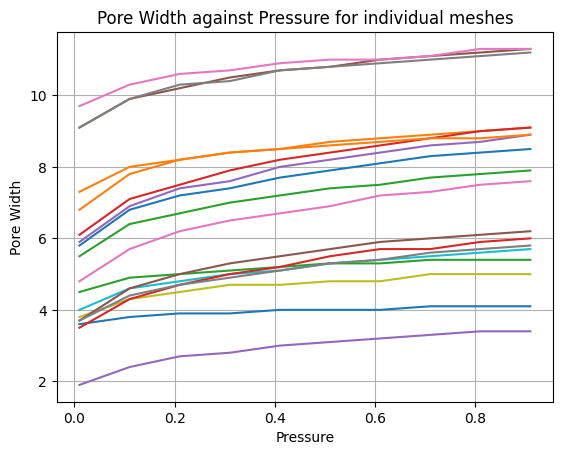

In [27]:
## Plot pore width against pressure for all individual meshes

meshes = data_aniso_40_200["Mesh"].unique()

for mesh in meshes:
    data = data_aniso_40_200[data_aniso_40_200["Mesh"] == mesh]
    plt.plot(data["Pressure"], data["Pore_width_end"], label=mesh)

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure for individual meshes')
#plt.legend()
plt.grid(True)
plt.show()





In [39]:
data_aniso_40_200_filtered["Mesh"].unique()

array(['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a',
       '2_7a', '3_1', '3_2', '3_4', '3_6', '3_7'], dtype=object)

In [3]:
## Metrics for onion meshes: calculated by hand (width, height)

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]



meshes = [mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_6a, mesh_2_6b, mesh_2_7a, mesh_3_1]

In [4]:
metrics = []

for mesh in meshes:
    metrics.append(mesh[0][0] / mesh[0][1])
    print(mesh[0][0] / mesh[0][1])
    metrics.append(mesh[1][0] / mesh[1][1])
    print(mesh[1][0] / mesh[1][1])

sum(metrics) / len(metrics)

1.6989247311827957
1.4954954954954958
1.4907407407407407
1.603960396039604
1.392857142857143
1.1896551724137931
1.4480000000000002
1.5130434782608695
1.4051724137931036
1.225806451612903
1.2434782608695654
1.3716814159292035
1.3137254901960786
1.4193548387096773
1.574074074074074
1.656862745098039
1.2857142857142856
1.4444444444444444
1.3238095238095238
1.1810344827586208
1.3394495412844036
1.3153153153153154


1.4060272927545303

In [5]:
import numpy as np
np.median(metrics)

np.float64(1.3990147783251232)

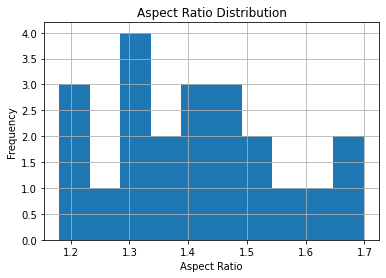

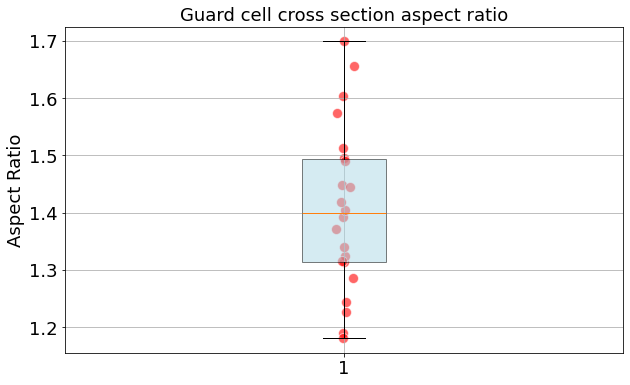

In [9]:
## Plot the spread of the aspect ratios (found in metrics)
import matplotlib.pyplot as plt

plt.hist(metrics, bins=10)
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.title('Aspect Ratio Distribution')
plt.grid(True)
plt.show()

## Plot it as a boxplot, with the individual data points overlaid

# Create a box plot with individual data points overlaid
plt.figure(figsize=(10, 6))

# Create the box plot with transparency
box = plt.boxplot(metrics, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.5))

# Overlay individual data points with jitter
x = np.random.normal(1, 0.01, size=len(metrics))  # Add jitter to the x-axis
plt.scatter(x, metrics, color='red', alpha=0.6, edgecolors='w', s=100)

# Add labels and title
plt.ylabel('Aspect Ratio', fontsize=18)
plt.title('Guard cell cross section aspect ratio', fontsize=18)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('aspect_ratio.png', dpi=300)

# Show the plot
plt.show()


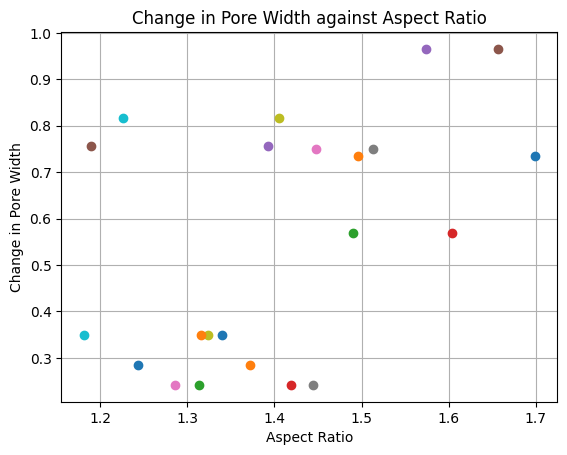

In [99]:
## Plot the aspect ratio against the change in pore width

data_set_meshes = ["1_2","1_3","1_4","1_5","1_6","1_8","2_1","2_6a","2_6b","2_7a","3_1"]
i = 0
for mesh in data_set_meshes:
    data = data_aniso_40_200[(data_aniso_40_200["Mesh"] == mesh) & (data_aniso_40_200["Pressure"] > 0.9)]
    metric1 = metrics[i]
    metric2 = metrics[i+1]
    plt.plot(metric1, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    plt.plot(metric2, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    i += 2

plt.xlabel('Aspect Ratio')
plt.ylabel('Change in Pore Width')
plt.title('Change in Pore Width against Aspect Ratio')
#plt.legend()
plt.grid(True)
plt.show()

### Flattening a Cylinder to Achieve a 1.44:1 Aspect Ratio

If you want to change the cross-section aspect ratio of a cylinder from **1:1 (a perfect circle)** to **1.44:1 (width:height)** by flattening it along the **z-axis**, you need to scale it in the **z-direction** by a factor \( s \).

#### Step-by-step calculation:

1. **Define the original cross-section:**
   - If the cylinder originally has a circular cross-section with radius \( r \), then both width (x-direction) and height (z-direction) are equal to \( 2r \).

2. **After flattening (scaling in z):**
   - Width remains **\( 2r \)**.
   - Height scales to **\( 2sr \)**, where \( s \) is the flattening factor in the z-direction.

3. **Set up the aspect ratio equation:**
   \[
   \frac{\text{width}}{\text{height}} = \frac{2r}{2sr} = \frac{1}{s} = 1.44
   \]

4. **Solve for \( s \):**
   \[
   s = \frac{1}{1.44} \approx 0.694
   \]

#### Conclusion:
To achieve a width:height ratio of **1.44:1**, you need to **scale (flatten) the cylinder in the z-direction by a factor of approximately 0.694**. This means the new height of the cross-section will be about **69.4% of the original height**.


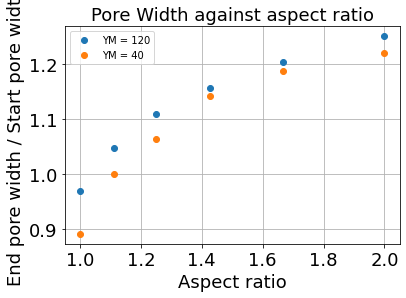

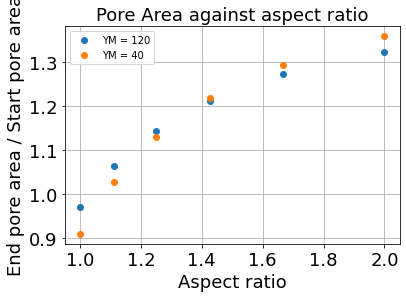

In [47]:
## 12 Mar. Idealised mesh: curve 1.75, radius 20, np 100, dist 6, cube 1, rad 7
## YM = 120

start_width = 6.4
start_area = 74.25

z_scale = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
z_scale = [1 /z for z in z_scale]
width = [8, 7.7, 7.4, 7.1, 6.7, 6.2]
area = [98.25, 94.51, 89.94, 84.83, 78.98, 71.99]

width_40 = [7.8, 7.6, 7.3, 6.8, 6.4, 5.7]
area_40 = [100.89, 96.07, 90.49, 83.83, 76.3, 67.51]

norm_width = [x / start_width for x in width]
norm_area = [x / start_area for x in area]

norm_width_40 = [x / start_width for x in width_40]
norm_area_40 = [x / start_area for x in area_40]

import matplotlib.pyplot as plt

plt.plot(z_scale, norm_width, 'o', label = "YM = 120")
plt.plot(z_scale, norm_width_40, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio', fontsize=18)
plt.ylabel('End pore width / Start pore width', fontsize=18)
plt.title('Pore Width against aspect ratio', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.grid(True)
plt.legend()
plt.show()

plt.plot(z_scale, norm_area, 'o', label = "YM = 120")
plt.plot(z_scale, norm_area_40, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio', fontsize=18)
plt.ylabel('End pore area / Start pore area', fontsize=18)
plt.title('Pore Area against aspect ratio', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.grid(True)
plt.legend()
plt.show()

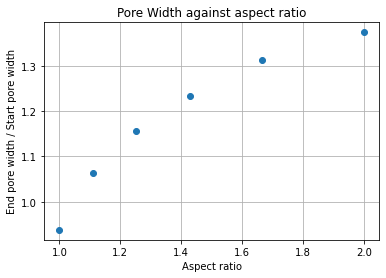

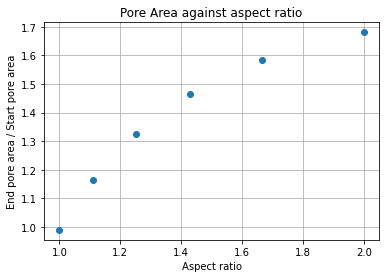

In [13]:
## Replot the above, but with the smooth idealised mesh

start_width = 6.4
start_area = 74.25

width = [8.8, 8.4, 7.9, 7.4, 6.8, 6]
area = [124.83, 117.61, 108.74, 98.42, 86.54, 73.46]

norm_width = [x / start_width for x in width]
norm_area = [x / start_area for x in area]

plt.plot(z_scale, norm_width, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio')
plt.ylabel('End pore width / Start pore width')
plt.title('Pore Width against aspect ratio')
plt.grid(True)
#plt.legend()
plt.savefig("pore_width_idealised.png", dpi = 300)
plt.show()

plt.plot(z_scale, norm_area, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio')
plt.ylabel('End pore area / Start pore area')
plt.title('Pore Area against aspect ratio')
plt.grid(True)
#plt.legend()
plt.savefig("pore_area_idealised.png", dpi = 300)
plt.show()

13 13 13 13


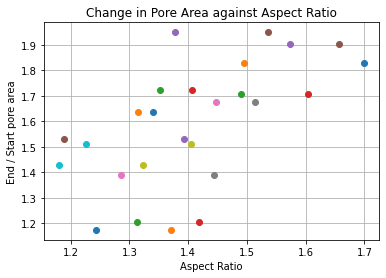

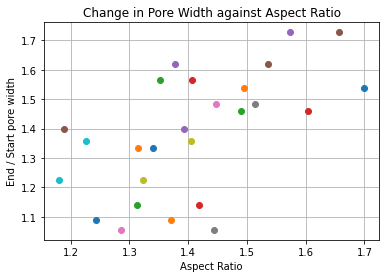

In [49]:
## Plot the aspect ratio and change in pore area / width for the smoothed meshes (YM = 40)

start_area = [51.8, 55.86, 51.24, 61.41, 67.84, 75.04, 81.07, 29.51, 21.5, 60.32, 29.93, 29.03, 15.8]
start_width = [5.4, 6.3, 5, 5.6, 5.6, 9.1, 9.3, 3.3, 3.6, 7.1, 4.2, 3.0, 2.1]

end_area = [94.78, 95.39, 78.44, 102.82, 102.59, 88.07, 97.72, 56.18, 29.83, 86.07, 49.02, 50.05, 30.79]
end_width = [8.3, 9.2, 7, 8.3, 7.6, 9.9, 10.6, 5.7, 3.8, 8.7, 5.6, 4.7, 3.4]

print(len(start_area), len(start_width), len(end_area), len(end_width))

                               
                                     
area_change = [(y) / x for x, y in zip(start_area, end_area)]
width_change = [(y) / x for x, y in zip(start_width, end_width)]

## Aspect ratios for each mesh (calculate by hand)

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]

meshes = [mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_6a, mesh_2_6b, mesh_2_7a, mesh_3_1, mesh_3_2, mesh_3_3]

for mesh, area in zip(meshes, area_change):
    plt.plot(mesh[0][0] / mesh[0][1], area, 'o')
    plt.plot(mesh[1][0] / mesh[1][1], area, 'o')

plt.xlabel('Aspect Ratio')
plt.ylabel('End / Start pore area')
plt.title('Change in Pore Area against Aspect Ratio')
plt.grid(True)
plt.savefig("area_change_confocal.png", dpi=300)
plt.show()

for mesh, width in zip(meshes, width_change):
    plt.plot(mesh[0][0] / mesh[0][1], width, 'o')
    plt.plot(mesh[1][0] / mesh[1][1], width, 'o')

plt.xlabel('Aspect Ratio')
plt.ylabel('End / Start pore width')
plt.title('Change in Pore Width against Aspect Ratio')
plt.grid(True)
plt.savefig("width_change_confocal.png", dpi=300)
plt.show()

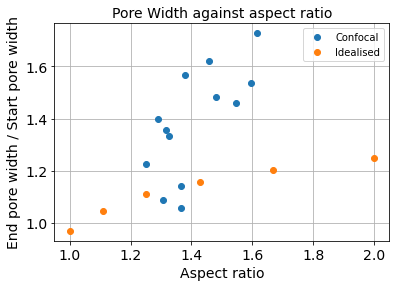

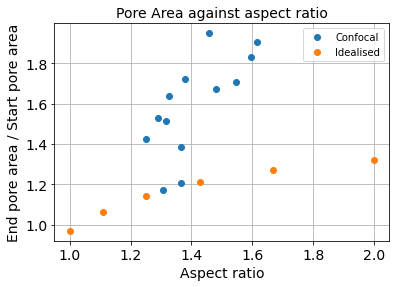

In [53]:
## Plot both the idealised and the confocal data on the same plot
## Let's try averaging the aspect ratios for the confocal data  

averaged_aspect_ratios = []

for mesh in meshes:
    av = (mesh[0][0] / mesh[0][1] + mesh[1][0] / mesh[1][1]) / 2
    averaged_aspect_ratios.append(av)

font = 14

plt.plot(averaged_aspect_ratios, width_change, 'o', label = "Confocal")
plt.plot(z_scale, norm_width, 'o', label = "Idealised")
plt.xlabel('Aspect ratio', fontsize=font)
plt.ylabel('End pore width / Start pore width', fontsize=font)
plt.title('Pore Width against aspect ratio', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True)
plt.legend()
plt.savefig("pore_width_comparison.png", dpi = 300, bbox_inches='tight')
plt.show()

plt.plot(averaged_aspect_ratios, area_change, 'o', label = "Confocal")
plt.plot(z_scale, norm_area, 'o', label = "Idealised")
plt.xlabel('Aspect ratio', fontsize=font)
plt.ylabel('End pore area / Start pore area', fontsize=font)
plt.title('Pore Area against aspect ratio', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True)
plt.legend()
plt.savefig("pore_area_comparison.png", dpi = 300, bbox_inches='tight')
plt.show()

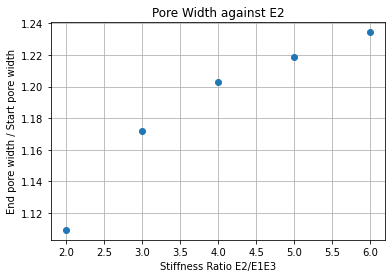

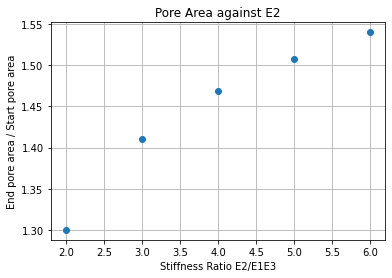

In [51]:
## Plot the change in E2 against the pore width for the idealised mesh

start_width = 6.4
start_area = 74.25

e2 = [2, 3, 4, 5, 6]
width_e2 = [7.1, 7.5, 7.7, 7.8, 7.9]
area_e2 = [96.54, 104.75, 109.06, 111.93, 114.34]

norm_width_e2 = [x / start_width for x in width_e2]
norm_area_e2 = [x / start_area for x in area_e2]

plt.plot(e2, norm_width_e2, 'o')
plt.xlabel('Stiffness Ratio E2/E1E3')
plt.ylabel('End pore width / Start pore width')
plt.title('Pore Width against E2')
plt.grid(True)
plt.savefig("pore_width_e2.png", dpi = 300)
plt.show()

plt.plot(e2, norm_area_e2, 'o')
plt.xlabel('Stiffness Ratio E2/E1E3')
plt.ylabel('End pore area / Start pore area')
plt.title('Pore Area against E2')
plt.grid(True)
plt.savefig("pore_area_e2.png", dpi = 300)
plt.show()


In [12]:
## For each mesh, we need the starting pore area, and the end pore area and width for each conditions: confocal, std, bulged

## Each mesh needs the correct scale setting.

scale_dict = {
    "1_2": 1.29,
    "1_3": 1.44,
    "1_4": 1.35,
    "1_5": 1.37,
    "1_6": 1.42,
    "1_8": 1.47,
    "2_1": 1.48,
    "2_3": 1.12,
    "2_6a": 1.21,
    "2_6b": 0.5,
    "2_7a": 0.5,
    "3_1": 0.5
}

import pandas as pd

# Create a list of dictionaries, where each dictionary is a row
data_rows = [
    {"Mesh": "1_2", "Start Area": 40.9, "End Area": 63.01, "Condition": "Confocal"},
    {"Mesh": "1_2", "Start Area": 39.8, "End Area": 47.05, "Condition": "Std"},
    {"Mesh": "1_2", "Start Area": 42.07, "End Area": 61.46, "Condition": "Bulged_preserved"},
    {"Mesh": "1_2", "Start Area": 39.83, "End Area": 52.56, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_3", "Start Area": 44.7, "End Area": 65.4, "Condition": "Confocal"},
    {"Mesh": "1_3", "Start Area": 44.96, "End Area": 49.49, "Condition": "Std"},
    {"Mesh": "1_3", "Start Area": 47.31, "End Area": 58.23, "Condition": "Bulged_preserved"},
    {"Mesh": "1_3", "Start Area": 44.96, "End Area": 53.2, "Condition": "Bulged_not_preserved"}
    ,
    {"Mesh": "1_4", "Start Area": 42.9, "End Area": 57.9, "Condition": "Confocal"},
    {"Mesh": "1_4", "Start Area": 42.07, "End Area": 44.9, "Condition": "Std"},
    {"Mesh": "1_4", "Start Area": 42.7, "End Area": 51.7, "Condition": "Bulged_preserved"},
    {"Mesh": "1_4", "Start Area": 42.1, "End Area": 49.3, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_5", "Start Area": 49.3, "End Area": 69.98, "Condition": "Confocal"},
    {"Mesh": "1_5", "Start Area": 50.95, "End Area": 54.8, "Condition": "Std"},
    {"Mesh": "1_5", "Start Area": 52.6, "End Area": 64.3, "Condition": "Bulged_preserved"},
    {"Mesh": "1_5", "Start Area": 50.95, "End Area": 60.45, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_6", "Start Area": 53.85, "End Area": 77.3, "Condition": "Confocal"},
    {"Mesh": "1_6", "Start Area": 53.16, "End Area": 53.8, "Condition": "Std"},
    {"Mesh": "1_6", "Start Area": 53.4, "End Area": 58.8, "Condition": "Bulged_preserved"},
    {"Mesh": "1_6", "Start Area": 53.16, "End Area": 59.09, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_8", "Start Area": 65.72, "End Area": 73.2, "Condition": "Confocal"},
    {"Mesh": "1_8", "Start Area": 64.93, "End Area": 63.02, "Condition": "Std"},
    {"Mesh": "1_8", "Start Area": 65.72, "End Area": 64.54, "Condition": "Bulged_preserved"},
    {"Mesh": "1_8", "Start Area": 64.9, "End Area": 64.92, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_1", "Start Area": 73.8, "End Area": 84.56, "Condition": "Confocal"},
    {"Mesh": "2_1", "Start Area": 73.99, "End Area": 77.01, "Condition": "Std"},
    {"Mesh": "2_1", "Start Area": 75.68, "End Area": 79.88, "Condition": "Bulged_preserved"},
    {"Mesh": "2_1", "Start Area": 73.99, "End Area": 78.6, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_3", "Start Area": 74.12, "End Area": 93.13, "Condition": "Confocal"},
    {"Mesh": "2_3", "Start Area": 73.2, "End Area": 80.3, "Condition": "Std"},
    {"Mesh": "2_3", "Start Area": 74.28, "End Area": 85.57, "Condition": "Bulged_preserved"},
    {"Mesh": "2_3", "Start Area": 73.2, "End Area": 84.05, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_6a", "Start Area": 21.6, "End Area": 33.29, "Condition": "Confocal"},
    {"Mesh": "2_6a", "Start Area": 22.3, "End Area": 33.18, "Condition": "Std"},
    {"Mesh": "2_6a", "Start Area": 21.6, "End Area": 41.3, "Condition": "Bulged_preserved"},
    {"Mesh": "2_6a", "Start Area": 22.33, "End Area": 42.85, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 70.8, "Condition": "Confocal"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Std"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Bulged_preserved"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Bulged_not_preserved"},
    {"Mesh": '2_7a', 'Start Area': 30.79, 'End Area': 31.9, 'Condition': 'Confocal'},
    {"Mesh":"2_7a", 'Start Area':30.79,'End Area':31.9,'Condition':'Std'},
]

# Create the DataFrame from the list of dictionaries
df_comparisons = pd.DataFrame(data_rows)

# You can then print or display the DataFrame to check
print(df_comparisons.head())

  Mesh  Start Area  End Area             Condition
0  1_2       40.90     63.01              Confocal
1  1_2       39.80     47.05                   Std
2  1_2       42.07     61.46      Bulged_preserved
3  1_2       39.83     52.56  Bulged_not_preserved
4  1_3       44.70     65.40              Confocal


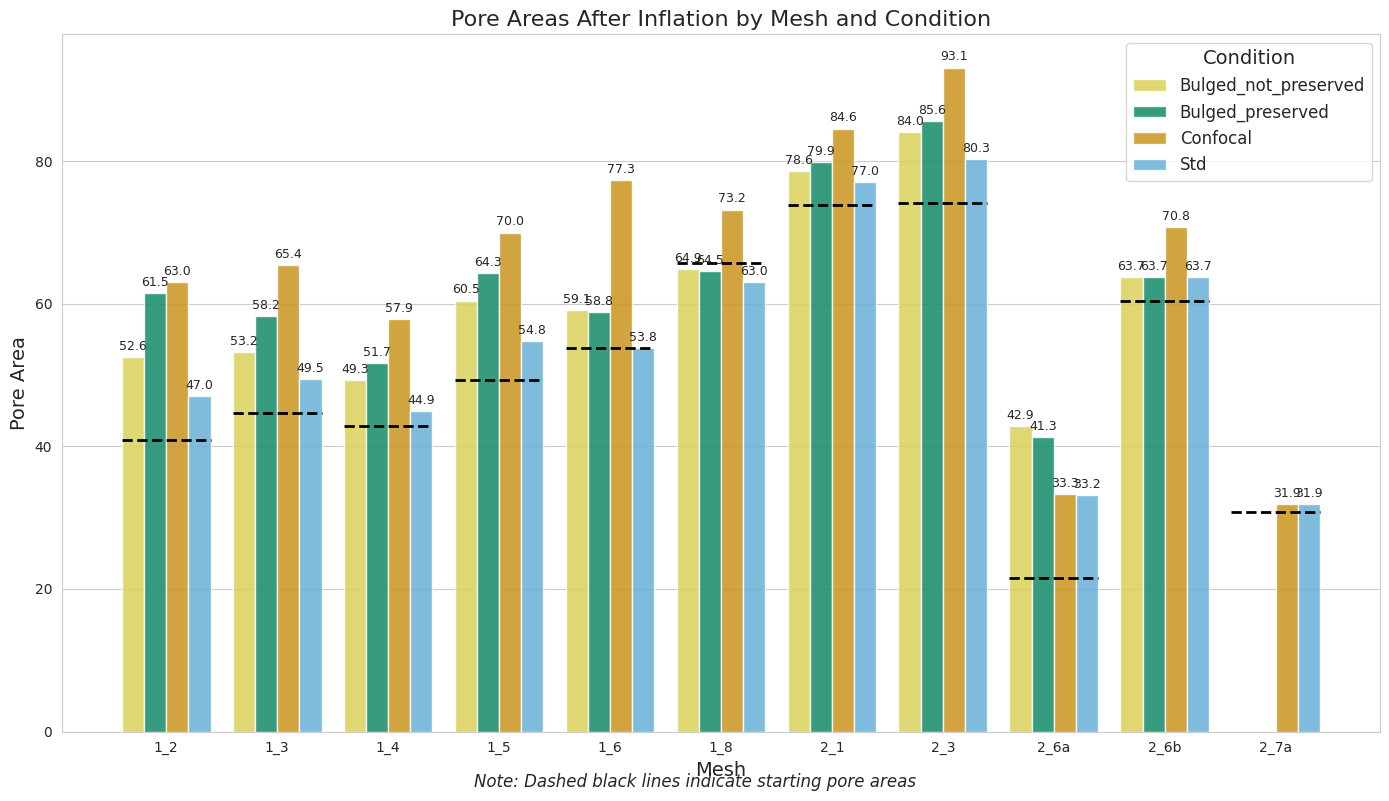

In [13]:
# Create a grouped bar chart showing end pore areas by mesh and condition
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set styling
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Sort for consistent ordering
df_comparisons_sorted = df_comparisons.sort_values(by=['Mesh', 'Condition'])

# Set up the plot
ax = sns.barplot(
    data=df_comparisons_sorted,
    x="Mesh", 
    y="End Area",
    hue="Condition",
    palette={"Confocal": "#E69F00", 
             "Std": "#56B4E9", 
             "Bulged_preserved": "#009E73", 
             "Bulged_not_preserved": "#F0E442"},
    alpha=0.85
)

# Add horizontal lines showing start areas for each mesh
for mesh in df_comparisons['Mesh'].unique():
    mesh_data = df_comparisons[df_comparisons['Mesh'] == mesh]
    # Get the first start area for this mesh (they're similar within each mesh)
    start_area = mesh_data['Start Area'].iloc[0]
    
    # Find x position for this mesh
    mesh_idx = list(ax.get_xticklabels())
    mesh_idx = [t.get_text() for t in mesh_idx].index(mesh)
    
    # Draw a horizontal dashed line for the start area
    line = ax.hlines(start_area, mesh_idx-0.4, mesh_idx+0.4, 
                     colors='black', linestyles='dashed', linewidth=2)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9, padding=3)

# Customize the plot
plt.title("Pore Areas After Inflation by Mesh and Condition", fontsize=16)
plt.xlabel("Mesh", fontsize=14)
plt.ylabel("Pore Area", fontsize=14)

# Add a legend with custom title
plt.legend(title="Condition", fontsize=12, title_fontsize=14)

# Add text explaining the dashed lines
plt.figtext(0.5, 0.01, "Note: Dashed black lines indicate starting pore areas", 
           ha="center", fontsize=12, style='italic')

plt.tight_layout()
plt.show()